# Part 3 - Evaluation and Metrics


## Train, Validation, Test

In [145]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Generate synthetic data
np.random.seed(1)
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + np.random.randn(100) * 0.3

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate performance
train_error = mean_squared_error(y_train, model.predict(X_train))
test_error = mean_squared_error(y_test, model.predict(X_test))

print(f"Training error: {train_error:.3f}")
print(f"Test error: {test_error:.3f}")

Training error: 0.073
Test error: 0.071


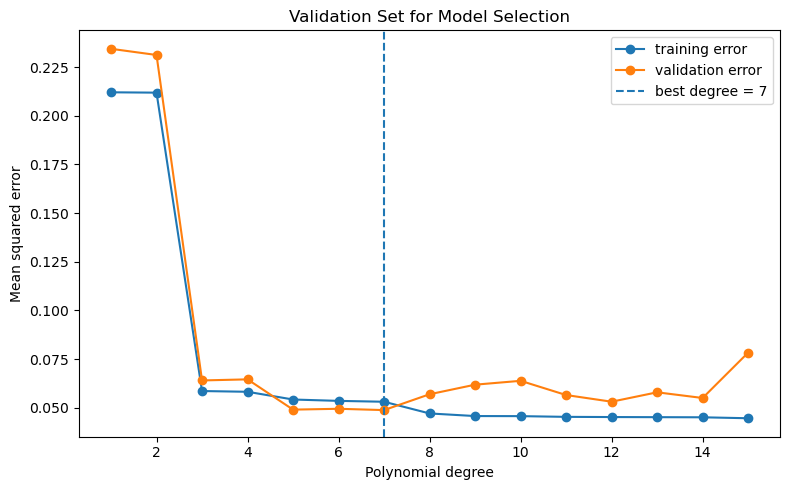

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(123)

# Generate synthetic data
X = np.linspace(-3, 3, 120)
y_true = np.sin(X)
y = y_true + np.random.normal(0, 0.2, size=len(X))

X = X.reshape(-1, 1)

# Train/validation/test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=0
)  # 0.25 x 0.8 = 0.2

degrees = range(1, 16)
train_errors = []
val_errors = []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    val_errors.append(mean_squared_error(y_val, y_val_pred))

best_degree = degrees[np.argmin(val_errors)]

# Plot training and validation errors
plt.figure(figsize=(8,5))
plt.plot(degrees, train_errors, marker='o', label='training error')
plt.plot(degrees, val_errors, marker='o', label='validation error')
plt.axvline(best_degree, linestyle='--', label=f'best degree = {best_degree}')
plt.xlabel('Polynomial degree')
plt.ylabel('Mean squared error')
plt.title('Validation Set for Model Selection')
plt.legend()
plt.tight_layout()
plt.savefig("/validation_set_model_selection.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Learning Curves

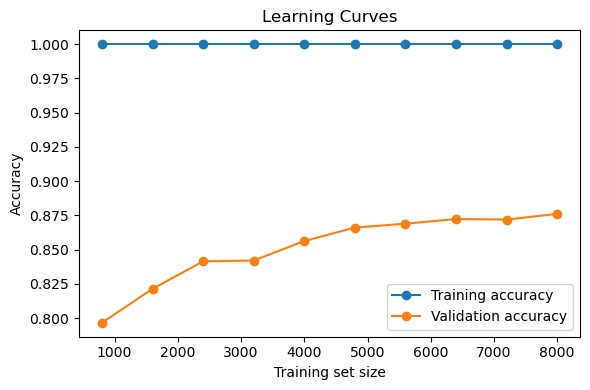

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier

# Generate synthetic classification data
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=0
)

model = DecisionTreeClassifier(max_depth=None, random_state=0)

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_mean, marker='o', label="Training accuracy")
plt.plot(train_sizes, val_mean, marker='o', label="Validation accuracy")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curves")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/learning_curves.pdf", dpi=300, bbox_inches="tight")

plt.show()

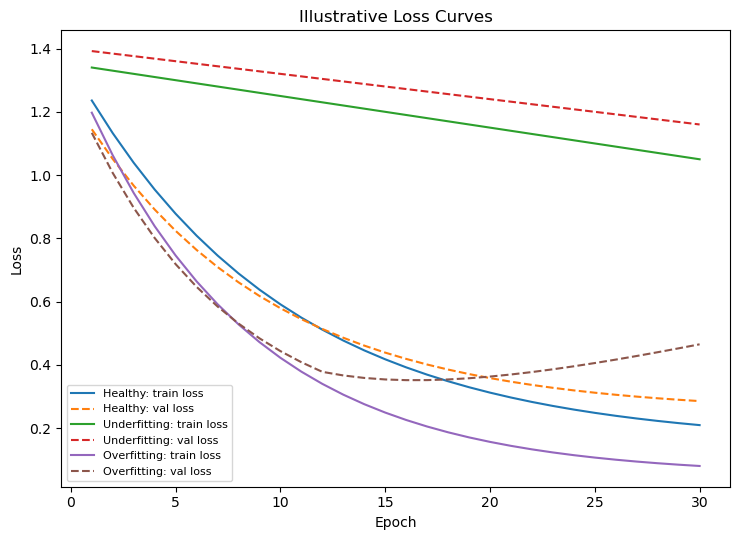

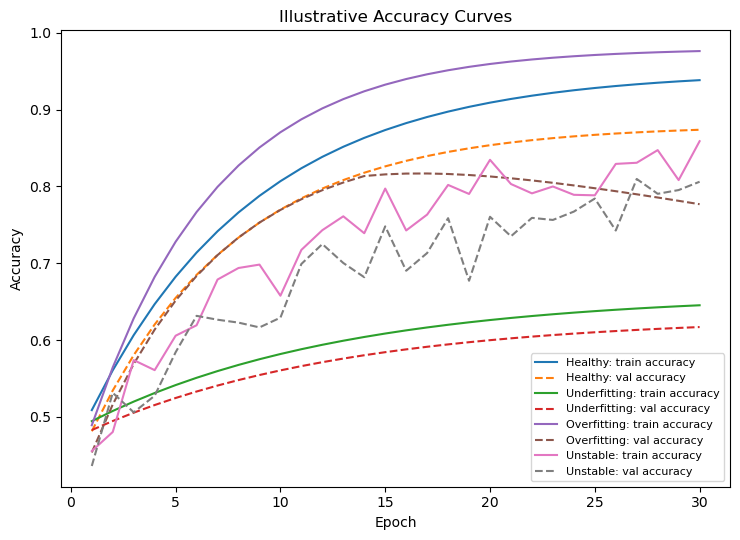

In [137]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 31)

# 1. Healthy learning
train_loss_good = 1.2 * np.exp(-epochs / 10) + 0.15
val_loss_good = 1.0 * np.exp(-epochs / 9) + 0.25
train_acc_good = 0.45 + 0.5 * (1 - np.exp(-epochs / 8))
val_acc_good = 0.42 + 0.46 * (1 - np.exp(-epochs / 7))

# 2. Underfitting
train_loss_under = 1.0 - 0.01 * epochs + 0.35
val_loss_under = 1.02 - 0.008 * epochs + 0.38
train_acc_under = 0.48 + 0.18 * (1 - np.exp(-epochs / 12))
val_acc_under = 0.47 + 0.16 * (1 - np.exp(-epochs / 12))

# 3. Overfitting
train_loss_over = 1.3 * np.exp(-epochs / 8) + 0.05
val_loss_over = 1.1 * np.exp(-epochs / 7) + 0.18 + 0.015 * np.maximum(epochs - 12, 0)
train_acc_over = 0.40 + 0.58 * (1 - np.exp(-epochs / 6))
val_acc_over = 0.38 + 0.48 * (1 - np.exp(-epochs / 6)) - 0.005 * np.maximum(epochs - 14, 0)

# 4. Unstable training
rng = np.random.default_rng(0)
train_loss_unstable = 0.9 * np.exp(-epochs / 11) + 0.25 + rng.normal(0, 0.05, size=len(epochs))
val_loss_unstable = 1.0 * np.exp(-epochs / 10) + 0.35 + rng.normal(0, 0.08, size=len(epochs))
train_acc_unstable = 0.42 + 0.42 * (1 - np.exp(-epochs / 9)) + rng.normal(0, 0.02, size=len(epochs))
val_acc_unstable = 0.40 + 0.38 * (1 - np.exp(-epochs / 8)) + rng.normal(0, 0.03, size=len(epochs))

plt.figure(figsize=(7.5, 5.5))
plt.plot(epochs, train_loss_good, label="Healthy: train loss")
plt.plot(epochs, val_loss_good, linestyle="--", label="Healthy: val loss")
plt.plot(epochs, train_loss_under, label="Underfitting: train loss")
plt.plot(epochs, val_loss_under, linestyle="--", label="Underfitting: val loss")
plt.plot(epochs, train_loss_over, label="Overfitting: train loss")
plt.plot(epochs, val_loss_over, linestyle="--", label="Overfitting: val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Illustrative Loss Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/Figures/learning_curve_loss_patterns.pdf", dpi=300, bbox_inches="tight")

plt.show()

plt.figure(figsize=(7.5, 5.5))
plt.plot(epochs, train_acc_good, label="Healthy: train accuracy")
plt.plot(epochs, val_acc_good, linestyle="--", label="Healthy: val accuracy")
plt.plot(epochs, train_acc_under, label="Underfitting: train accuracy")
plt.plot(epochs, val_acc_under, linestyle="--", label="Underfitting: val accuracy")
plt.plot(epochs, train_acc_over, label="Overfitting: train accuracy")
plt.plot(epochs, val_acc_over, linestyle="--", label="Overfitting: val accuracy")
plt.plot(epochs, train_acc_unstable, label="Unstable: train accuracy")
plt.plot(epochs, val_acc_unstable, linestyle="--", label="Unstable: val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Illustrative Accuracy Curves")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/learning_curve_accuracy_patterns.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
Data leakage

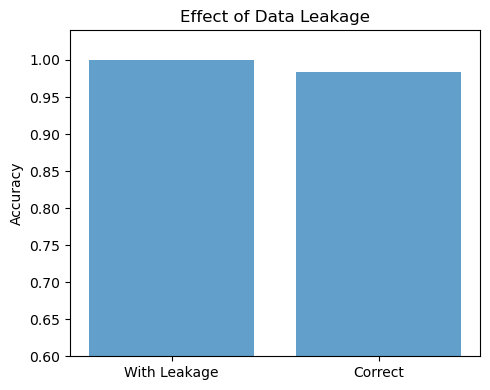

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.random.seed(0)

# Generate synthetic classification data
X = np.random.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Incorrect: scaling before split (leakage)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=123
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc_leak = accuracy_score(y_test, y_pred)

# Correct: scaling after split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
acc_correct = accuracy_score(y_test, y_pred)

# Visual comparison
labels = ["With Leakage", "Correct"]
values = [acc_leak, acc_correct]

plt.figure(figsize=(5,4))
plt.bar(labels, values, alpha=0.7)
plt.ylim(0.6, 1.04)
plt.ylabel("Accuracy")
plt.title("Effect of Data Leakage")
plt.tight_layout()
plt.savefig("/leakage_comparison.pdf", dpi=300, bbox_inches="tight")

plt.show()

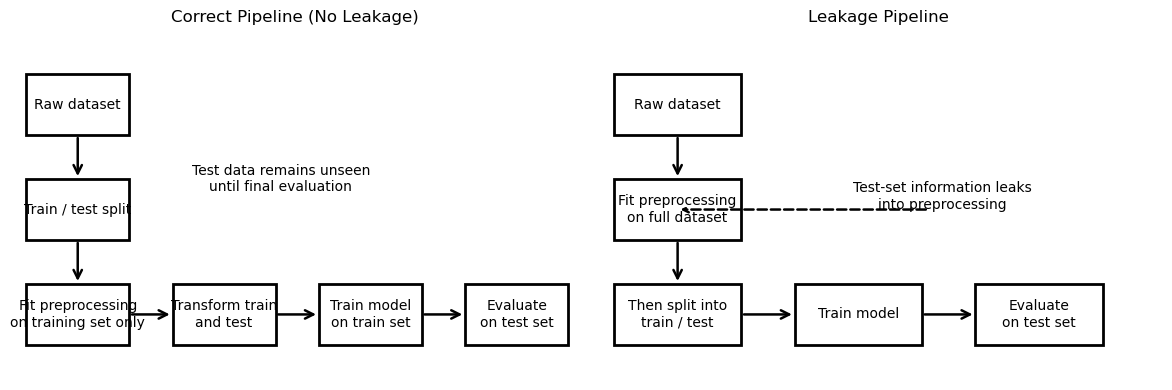

In [32]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------- helper functions ----------
def add_box(ax, xy, text, width=1.9, height=0.7):
    x, y = xy
    rect = Rectangle((x, y), width, height, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center', fontsize=10)
    return rect

def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=15, linewidth=1.8)
    ax.add_patch(arrow)

# ---------- left panel: correct pipeline ----------
ax = axes[0]
ax.set_title("Correct Pipeline (No Leakage)", fontsize=12)

add_box(ax, (0.3, 2.8), "Raw dataset")
add_box(ax, (0.3, 1.6), "Train / test split")
add_box(ax, (0.3, 0.4), "Fit preprocessing\non training set only")
add_box(ax, (3.0, 0.4), "Transform train\nand test")
add_box(ax, (5.7, 0.4), "Train model\non train set")
add_box(ax, (8.4, 0.4), "Evaluate\non test set")

add_arrow(ax, (1.25, 2.8), (1.25, 2.3))
add_arrow(ax, (1.25, 1.6), (1.25, 1.1))
add_arrow(ax, (2.2, 0.75), (3.0, 0.75))
add_arrow(ax, (4.9, 0.75), (5.7, 0.75))
add_arrow(ax, (7.6, 0.75), (8.4, 0.75))

ax.text(5.0, 2.3,
        "Test data remains unseen\nuntil final evaluation",
        ha='center', va='center', fontsize=10)

ax.set_xlim(0, 10.5)
ax.set_ylim(0, 4)
ax.axis('off')

# ---------- right panel: leakage pipeline ----------
ax = axes[1]
ax.set_title("Leakage Pipeline", fontsize=12)

add_box(ax, (0.3, 2.8), "Raw dataset")
add_box(ax, (0.3, 1.6), "Fit preprocessing\non full dataset")
add_box(ax, (0.3, 0.4), "Then split into\ntrain / test")
add_box(ax, (3.0, 0.4), "Train model")
add_box(ax, (5.7, 0.4), "Evaluate\non test set")

add_arrow(ax, (1.25, 2.8), (1.25, 2.3))
add_arrow(ax, (1.25, 1.6), (1.25, 1.1))
add_arrow(ax, (2.2, 0.75), (3.0, 0.75))
add_arrow(ax, (4.9, 0.75), (5.7, 0.75))

# leakage warning
ax.text(5.2, 2.1,
        "Test-set information leaks\ninto preprocessing",
        ha='center', va='center', fontsize=10)
ax.annotate("",
            xy=(1.25, 1.95), xytext=(5.0, 1.95),
            arrowprops=dict(arrowstyle='->', linewidth=1.8, linestyle='--'))

ax.set_xlim(0, 8.5)
ax.set_ylim(0, 4)
ax.axis('off')

plt.tight_layout()
plt.savefig("/Figures/leakage_pipeline", dpi=300, bbox_inches="tight")

plt.show()


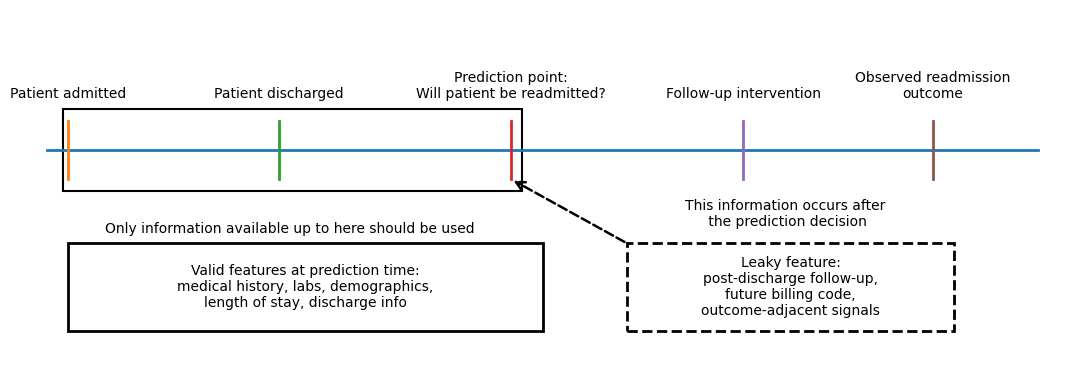

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 3.8))

# Timeline
ax.plot([0.8, 10.2], [1.8, 1.8], linewidth=2)

events = [
    (1.0, "Patient admitted"),
    (3.0, "Patient discharged"),
    (5.2, "Prediction point:\nWill patient be readmitted?"),
    (7.4, "Follow-up intervention"),
    (9.2, "Observed readmission\noutcome")
]

for x, label in events:
    ax.plot([x, x], [1.55, 2.05], linewidth=2)
    ax.text(x, 2.22, label, ha='center', va='bottom', fontsize=10)

# Correct features box
correct_box = Rectangle((1.0, 0.25), 4.5, 0.75, fill=False, linewidth=2)
ax.add_patch(correct_box)
ax.text(3.25, 0.625,
        "Valid features at prediction time:\nmedical history, labs, demographics,\nlength of stay, discharge info",
        ha='center', va='center', fontsize=10)

# Leakage feature box
leak_box = Rectangle((6.3, 0.25), 3.1, 0.75, fill=False, linewidth=2, linestyle='--')
ax.add_patch(leak_box)
ax.text(7.85, 0.625,
        "Leaky feature:\npost-discharge follow-up,\nfuture billing code,\noutcome-adjacent signals",
        ha='center', va='center', fontsize=10)

# Arrow from leakage box to prediction point
arrow = FancyArrowPatch((6.3, 1.0), (5.2, 1.55),
                        arrowstyle='->', mutation_scale=16,
                        linewidth=1.8, linestyle='--')
ax.add_patch(arrow)

ax.text(7.8, 1.25,
        "This information occurs after\n the prediction decision",
        ha='center', va='center', fontsize=10)

# Prediction window highlight
pred_window = Rectangle((0.95, 1.45), 4.35, 0.7, fill=False, linewidth=1.5)
ax.add_patch(pred_window)
ax.text(3.1, 1.12, "Only information available up to here should be used",
        ha='center', va='center', fontsize=10)

ax.set_xlim(0.5, 10.5)
ax.set_ylim(0, 3)
ax.axis('off')

plt.tight_layout()
plt.savefig("/Figures/feature_leakage_timeline.pdf", dpi=300, bbox_inches="tight")

plt.show()


## Cross Validation

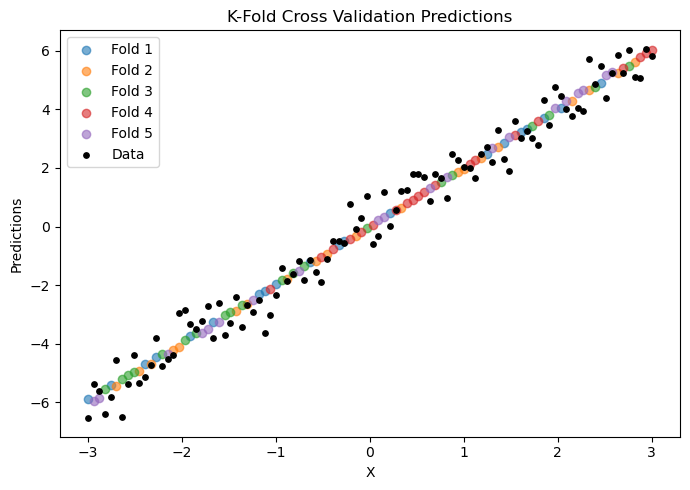

Cross-validation errors: [0.2753986177764192, 0.27991041734281913, 0.39607551084826, 0.3771408573875535, 0.35829661672187557]
Average CV error: 0.3373644040153855


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(123)

# Generate synthetic data
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 2 * X.squeeze() + np.random.randn(100) * 0.5

kf = KFold(n_splits=5, shuffle=True, random_state=42)

errors = []

plt.figure(figsize=(7,5))

for i, (train_index, val_index) in enumerate(kf.split(X)):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    error = mean_squared_error(y_val, y_pred)
    errors.append(error)

    # Plot validation predictions
    plt.scatter(X_val, y_pred, label=f"Fold {i+1}", alpha=0.6)

plt.scatter(X, y, color='black', s=15, label="Data")
plt.title("K-Fold Cross Validation Predictions")
plt.xlabel("X")
plt.ylabel("Predictions")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/kfold_cv.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("Cross-validation errors:", errors)
print("Average CV error:", np.mean(errors))

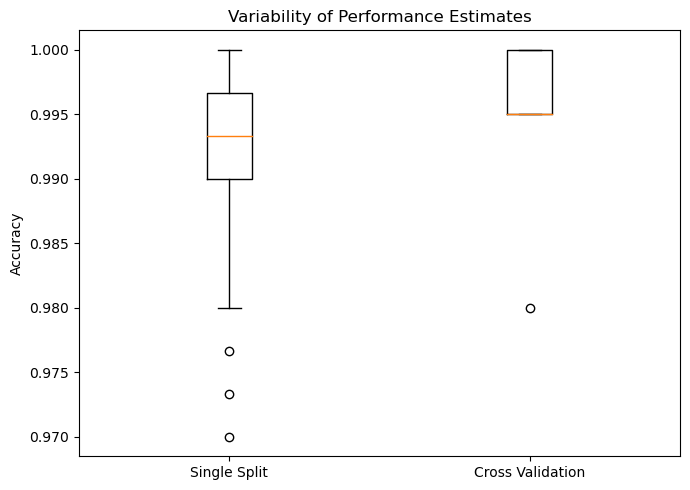

Single split mean: 0.9919666666666668
CV mean: 0.994


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression

np.random.seed(123)

# Generate synthetic classification data
X = np.random.randn(1000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

model = LogisticRegression()

# Single split results (repeated)
single_split_scores = []

for _ in range(100):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.3
    )
    model.fit(X_train, y_train)
    score = model.score(X_val, y_val)
    single_split_scores.append(score)

# Cross-validation results
cv_scores = cross_val_score(model, X, y, cv=5)

# Plot results
plt.figure(figsize=(7,5))
plt.boxplot([single_split_scores, cv_scores], labels=["Single Split", "Cross Validation"])
plt.ylabel("Accuracy")
plt.title("Variability of Performance Estimates")
plt.tight_layout()
plt.savefig("/Figures/cv_variability.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("Single split mean:", np.mean(single_split_scores))
print("CV mean:", np.mean(cv_scores))

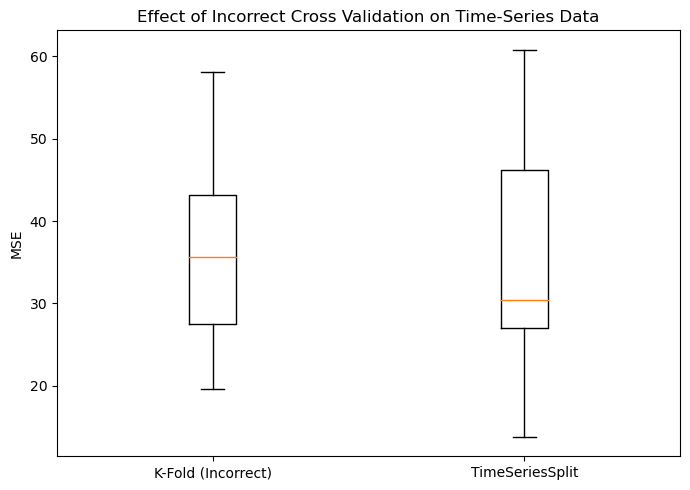

K-Fold errors: [43.18502012132151, 35.60125928015653, 27.538360323989387, 19.66172714833571, 58.11879337130033]
TimeSeriesSplit errors: [46.153805216824765, 30.461205955216975, 13.799144980786377, 27.033947794738893, 60.7907817677915]


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(0)

# Simulated time-series data
t = np.arange(100)
X = t.reshape(-1, 1)
y = 0.5 * t + np.random.randn(100) * 5

# Standard K-Fold (incorrect for time-series)
kf = KFold(n_splits=5)
kf_errors = []

for train_idx, val_idx in kf.split(X):
    model = LinearRegression()
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[val_idx])
    kf_errors.append(mean_squared_error(y[val_idx], y_pred))

# TimeSeriesSplit (correct approach)
tscv = TimeSeriesSplit(n_splits=5)
ts_errors = []

for train_idx, val_idx in tscv.split(X):
    model = LinearRegression()
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict(X[val_idx])
    ts_errors.append(mean_squared_error(y[val_idx], y_pred))

# Plot comparison
plt.figure(figsize=(7,5))
plt.boxplot([kf_errors, ts_errors], labels=["K-Fold (Incorrect)", "TimeSeriesSplit"])
plt.ylabel("MSE")
plt.title("Effect of Incorrect Cross Validation on Time-Series Data")
plt.tight_layout()
plt.savefig("/Figures/cv_time_series.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("K-Fold errors:", kf_errors)
print("TimeSeriesSplit errors:", ts_errors)

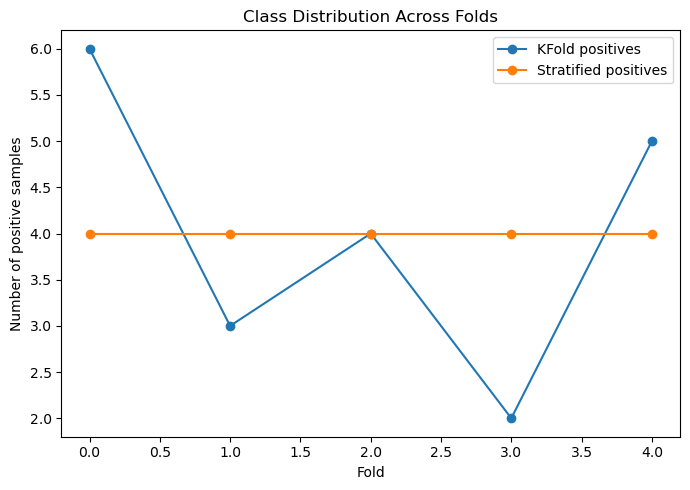

KFold positives per fold: [6, 3, 4, 2, 5]
Stratified positives per fold: [4, 4, 4, 4, 4]


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold

np.random.seed(12)

# Imbalanced dataset
X = np.random.randn(200, 2)
y = np.array([0]*180 + [1]*20)

kf = KFold(n_splits=5, shuffle=True, random_state=123)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

kf_class_counts = []
skf_class_counts = []

# Standard KFold
for _, val_idx in kf.split(X):
    y_val = y[val_idx]
    kf_class_counts.append(np.sum(y_val))

# Stratified KFold
for _, val_idx in skf.split(X, y):
    y_val = y[val_idx]
    skf_class_counts.append(np.sum(y_val))

# Plot
plt.figure(figsize=(7,5))
plt.plot(kf_class_counts, marker='o', label="KFold positives")
plt.plot(skf_class_counts, marker='o', label="Stratified positives")
plt.xlabel("Fold")
plt.ylabel("Number of positive samples")
plt.title("Class Distribution Across Folds")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/cv_stratified.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("KFold positives per fold:", kf_class_counts)
print("Stratified positives per fold:", skf_class_counts)

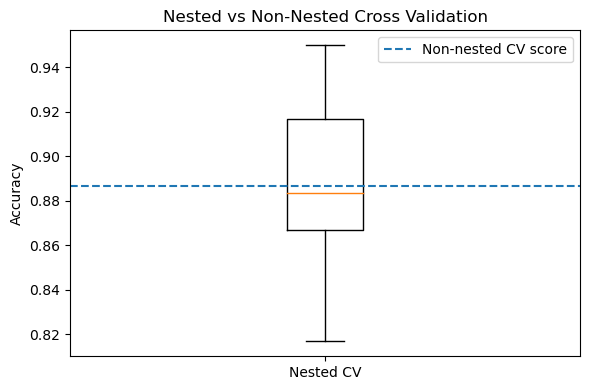

Nested CV scores: [0.86666667 0.95       0.81666667 0.91666667 0.88333333]
Mean nested score: 0.8866666666666667
Non-nested score: 0.8866666666666667


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.linear_model import LogisticRegression

# Generate synthetic data
X, y = make_classification(n_samples=300, n_features=10, random_state=123)

# Model and hyperparameter grid
model = LogisticRegression(max_iter=1000)
param_grid = {"C": [0.01, 0.1, 1, 10]}

# Inner loop (hyperparameter tuning)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=123)
grid_search = GridSearchCV(model, param_grid, cv=inner_cv)

# Outer loop (evaluation)
outer_cv = KFold(n_splits=5, shuffle=True, random_state=123)

nested_scores = cross_val_score(grid_search, X, y, cv=outer_cv)

# Non-nested approach (biased)
grid_search.fit(X, y)
non_nested_score = grid_search.best_score_

# Plot comparison
plt.figure(figsize=(6,4))
plt.boxplot([nested_scores], labels=["Nested CV"])
plt.axhline(non_nested_score, linestyle='--', label="Non-nested CV score")
plt.ylabel("Accuracy")
plt.title("Nested vs Non-Nested Cross Validation")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/cv_nested.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("Nested CV scores:", nested_scores)
print("Mean nested score:", np.mean(nested_scores))
print("Non-nested score:", non_nested_score)

In [ ]:
Classification Metrics

Accuracy: 0.90


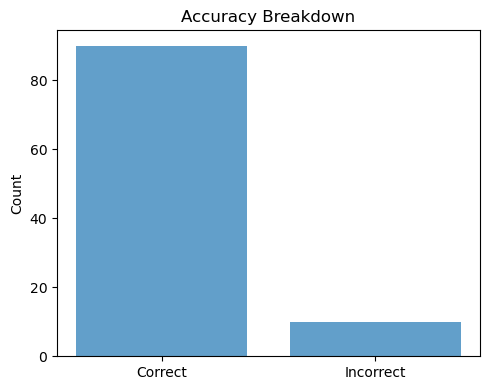

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Simulated true labels (imbalanced)
y_true = np.array([0]*90 + [1]*10)

# Model predicts all zeros
y_pred = np.zeros_like(y_true)

acc = accuracy_score(y_true, y_pred)

print(f"Accuracy: {acc:.2f}")

# Visualisation
labels = ["Correct", "Incorrect"]
values = [np.sum(y_true == y_pred), np.sum(y_true != y_pred)]

plt.figure(figsize=(5,4))
plt.bar(labels, values, alpha=0.7)
plt.title("Accuracy Breakdown")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("/Figures/accuracy_imbalance.pdf", dpi=300, bbox_inches="tight")

plt.show()

Precision: 0.75


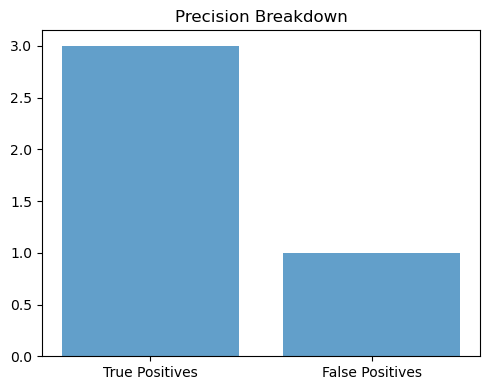

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score

# Simulated data
y_true = np.array([1,1,1,1,1,0,0,0,0,0])
y_pred = np.array([1,1,1,0,0,1,0,0,0,0])

precision = precision_score(y_true, y_pred)
print(f"Precision: {precision:.2f}")

# Visualisation
labels = ["True Positives", "False Positives"]
values = [np.sum((y_true==1)&(y_pred==1)),
          np.sum((y_true==0)&(y_pred==1))]

plt.figure(figsize=(5,4))
plt.bar(labels, values, alpha=0.7)
plt.title("Precision Breakdown")
plt.tight_layout()
plt.savefig("/Figures/precision.pdf", dpi=300, bbox_inches="tight")

plt.show()

Recall: 0.60


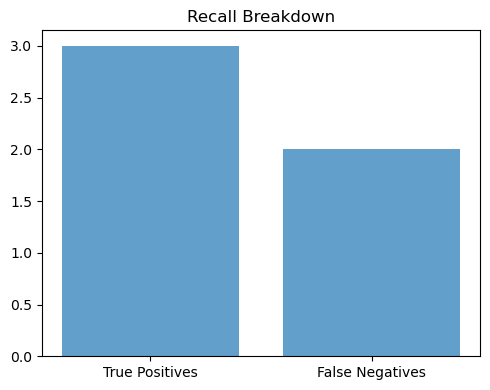

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score

# Simulated data
y_true = np.array([1,1,1,1,1,0,0,0,0,0])
y_pred = np.array([1,1,1,0,0,1,0,0,0,0])

recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.2f}")

# Visualisation
labels = ["True Positives", "False Negatives"]
values = [np.sum((y_true==1)&(y_pred==1)),
          np.sum((y_true==1)&(y_pred==0))]

plt.figure(figsize=(5,4))
plt.bar(labels, values, alpha=0.7)
plt.title("Recall Breakdown")
plt.tight_layout()
plt.savefig("/Figures/recall.pdf", dpi=300, bbox_inches="tight")
plt.show()

Precision: 0.75
Recall: 0.60
F1 score: 0.67


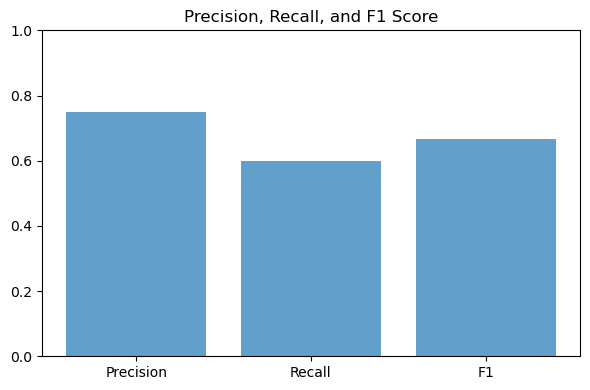

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

# Simulated predictions
y_true = np.array([1,1,1,1,1,0,0,0,0,0])
y_pred = np.array([1,1,1,0,0,1,0,0,0,0])

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 score: {f1:.2f}")

# Visualisation
labels = ["Precision", "Recall", "F1"]
values = [precision, recall, f1]

plt.figure(figsize=(6,4))
plt.bar(labels, values, alpha=0.7)
plt.ylim(0,1)
plt.title("Precision, Recall, and F1 Score")
plt.show()

Accuracy: 0.95
Balanced Accuracy: 0.50


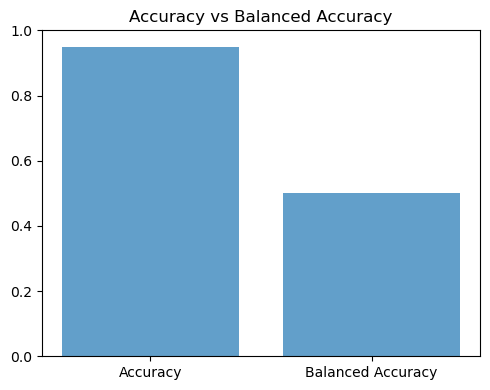

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Imbalanced dataset
y_true = np.array([0]*95 + [1]*5)

# Predict all zeros
y_pred = np.zeros_like(y_true)

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"Accuracy: {acc:.2f}")
print(f"Balanced Accuracy: {bal_acc:.2f}")

# Visualisation
labels = ["Accuracy", "Balanced Accuracy"]
values = [acc, bal_acc]

plt.figure(figsize=(5,4))
plt.bar(labels, values, alpha=0.7)
plt.ylim(0,1)
plt.title("Accuracy vs Balanced Accuracy")
plt.tight_layout()
plt.savefig("/Figures/balanced_accuracy.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
Confusion Matrix

Confusion Matrix:
 [[4 1]
 [2 3]]
Precision: 0.75
Recall: 0.60
F1 Score: 0.67


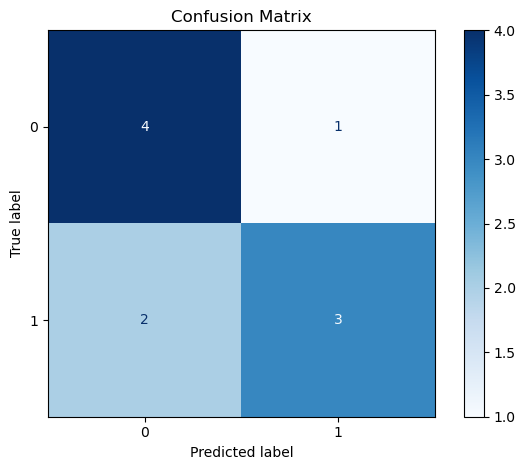

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

# Simulated data
y_true = np.array([1,1,1,1,1,0,0,0,0,0])
y_pred = np.array([1,1,0,1,0,1,0,0,0,0])

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:\n", cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()

plt.savefig("/Figures/confusion_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

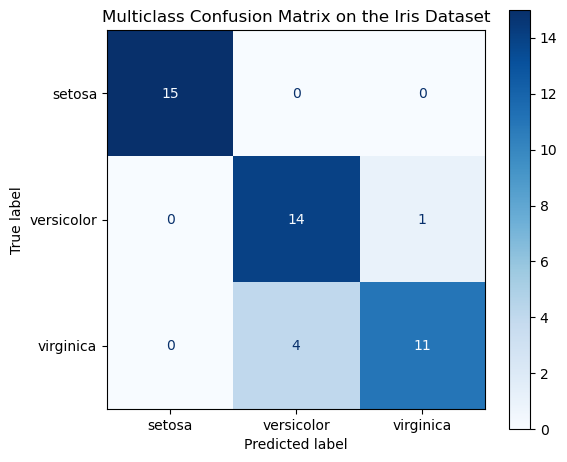

In [70]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# Load a simple multiclass dataset
iris = load_iris()
X = iris.data
y = iris.target
class_names = iris.target_names

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train a classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=class_names,
    cmap="Blues",
    ax=ax
)
plt.title("Multiclass Confusion Matrix on the Iris Dataset")
plt.tight_layout()
plt.savefig("/Figures/confusion_matrix_multiclass.pdf", dpi=300, bbox_inches="tight")

plt.show()

## ROC curves

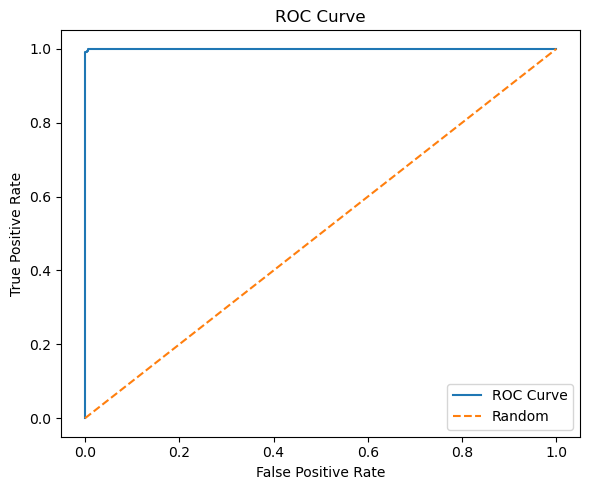

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.linear_model import LogisticRegression

# Generate synthetic data
np.random.seed(0)
X = np.random.randn(2000, 3)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

model = LogisticRegression()
model.fit(X, y)

y_scores = model.predict_proba(X)[:, 1]

fpr, tpr, thresholds = roc_curve(y, y_scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
#plt.savefig("/Figures/roc_curve.pdf", dpi=300, bbox_inches="tight")

plt.show()

AUC: 1.000


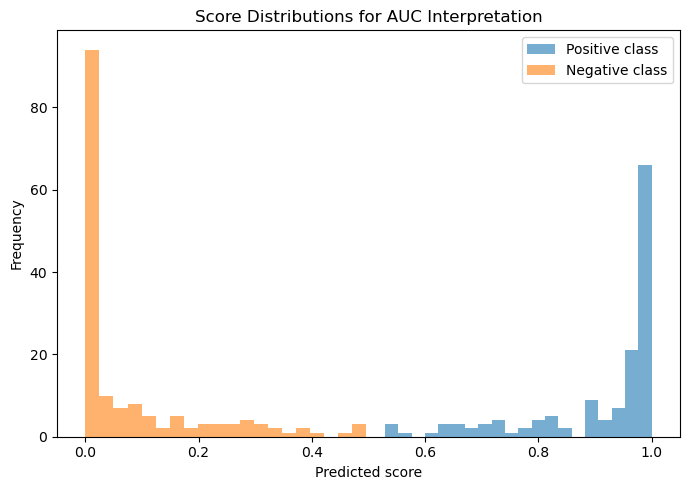

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# Generate synthetic data
np.random.seed(0)
X = np.random.randn(300, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

model = LogisticRegression()
model.fit(X, y)

y_scores = model.predict_proba(X)[:, 1]

auc = roc_auc_score(y, y_scores)
print(f"AUC: {auc:.3f}")

# Visualise score distributions
pos_scores = y_scores[y == 1]
neg_scores = y_scores[y == 0]

plt.figure(figsize=(7,5))
plt.hist(pos_scores, bins=20, alpha=0.6, label="Positive class")
plt.hist(neg_scores, bins=20, alpha=0.6, label="Negative class")
plt.title("Score Distributions for AUC Interpretation")
plt.xlabel("Predicted score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/auc_distribution.pdf", dpi=300, bbox_inches="tight")

plt.show()

ROC AUC: 0.723


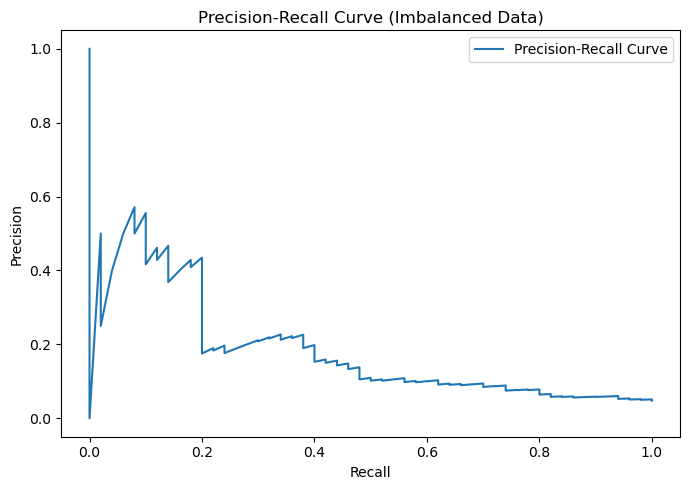

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve

np.random.seed(1)

# Imbalanced dataset
n_neg = 1000
n_pos = 50

# Generate scores
neg_scores = np.random.normal(0, 1, n_neg)
pos_scores = np.random.normal(1, 1, n_pos)

y_true = np.array([0]*n_neg + [1]*n_pos)
y_scores = np.concatenate([neg_scores, pos_scores])

# Compute AUC
auc = roc_auc_score(y_true, y_scores)
print(f"ROC AUC: {auc:.3f}")

# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Imbalanced Data)")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/pr_curve_imbalance.pdf", dpi=300, bbox_inches="tight")

plt.show()

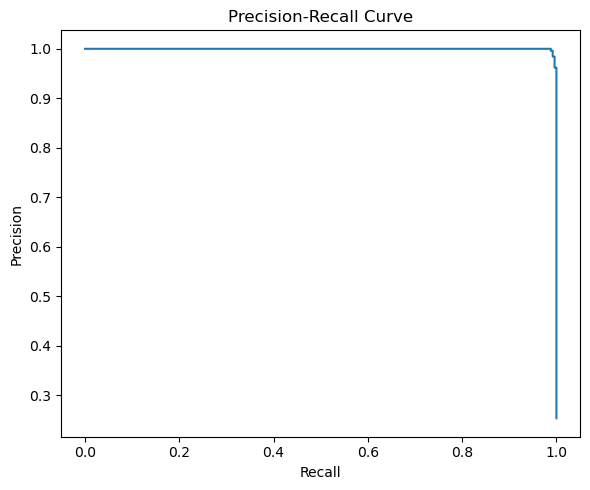

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.linear_model import LogisticRegression

# Generate synthetic data
np.random.seed(1)
X = np.random.randn(1000, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

model = LogisticRegression()
model.fit(X, y)

y_scores = model.predict_proba(X)[:, 1]

precision, recall, thresholds = precision_recall_curve(y, y_scores)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig("/Figures/pr_curve.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Precision - Recall curves

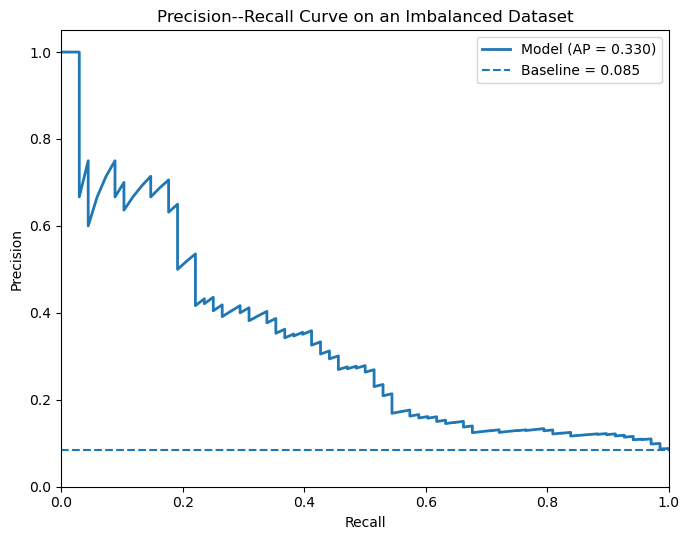

In [89]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

# Create an imbalanced binary classification dataset
X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=4,
    n_redundant=2,
    n_clusters_per_class=2,
    weights=[0.92, 0.08],
    class_sep=1.0,
    flip_y=0.01,
    random_state=0
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=0
)

# Train a classifier
model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(X_train, y_train)

# Predicted probabilities for the positive class
y_scores = model.predict_proba(X_test)[:, 1]

# Precision-recall curve and average precision
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
ap = average_precision_score(y_test, y_scores)

# Baseline precision equals the positive class prevalence
baseline = np.mean(y_test)

# Plot precision-recall curve
plt.figure(figsize=(7, 5.5))
plt.plot(recall, precision, linewidth=2, label=f"Model (AP = {ap:.3f})")
plt.hlines(
    baseline, xmin=0, xmax=1,
    linestyles="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision--Recall Curve on an Imbalanced Dataset")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("/pr_curve_imbalanced_binary.pdf", dpi=300, bbox_inches="tight")
plt.show()


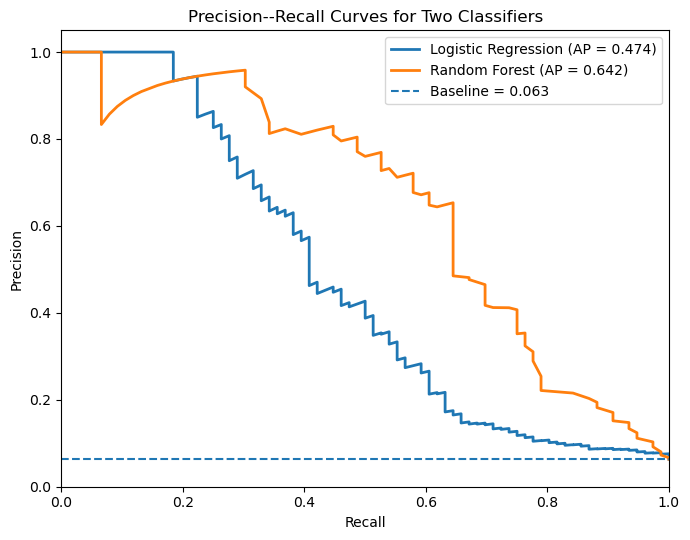

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

# Create an imbalanced binary classification dataset
X, y = make_classification(
    n_samples=3000,
    n_features=12,
    n_informative=5,
    n_redundant=3,
    n_clusters_per_class=2,
    weights=[0.94, 0.06],
    class_sep=0.9,
    flip_y=0.01,
    random_state=0
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=0
)

# Train two different classifiers
log_reg = LogisticRegression(max_iter=1000, random_state=0)
rf = RandomForestClassifier(n_estimators=200, random_state=0)

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predicted probabilities for the positive class
log_reg_scores = log_reg.predict_proba(X_test)[:, 1]
rf_scores = rf.predict_proba(X_test)[:, 1]

# Precision-recall curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, log_reg_scores)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_scores)

# Average precision scores
ap_lr = average_precision_score(y_test, log_reg_scores)
ap_rf = average_precision_score(y_test, rf_scores)

# Baseline precision equals the positive class prevalence
baseline = np.mean(y_test)

# Plot the curves
plt.figure(figsize=(7, 5.5))
plt.plot(recall_lr, precision_lr, linewidth=2,
         label=f"Logistic Regression (AP = {ap_lr:.3f})")
plt.plot(recall_rf, precision_rf, linewidth=2,
         label=f"Random Forest (AP = {ap_rf:.3f})")
plt.hlines(
    baseline, xmin=0, xmax=1,
    linestyles="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision--Recall Curves for Two Classifiers")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/pr_curve_two.pdf", dpi=300, bbox_inches="tight")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Simulated probabilities and labels
np.random.seed(0)
y_true = np.array([1]*50 + [0]*150)
y_scores = np.concatenate([
    np.random.uniform(0.5, 1.0, 50),
    np.random.uniform(0.0, 0.7, 150)
])

thresholds = np.linspace(0, 1, 50)
precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)
    precisions.append(precision_score(y_true, y_pred))
    recalls.append(recall_score(y_true, y_pred))

plt.figure(figsize=(6,5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/pr_tradeoff.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
Regression Metrics

MSE: 1.50


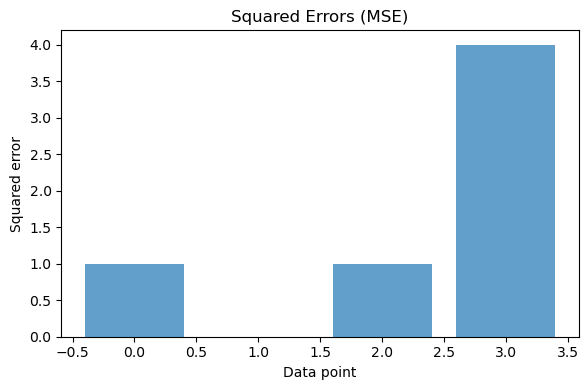

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# True and predicted values
y_true = np.array([2, 4, 6, 8])
y_pred = np.array([3, 4, 7, 10])

mse = mean_squared_error(y_true, y_pred)
print(f"MSE: {mse:.2f}")

# Visualisation
errors = y_true - y_pred

plt.figure(figsize=(6,4))
plt.bar(range(len(errors)), errors**2, alpha=0.7)
plt.xlabel("Data point")
plt.ylabel("Squared error")
plt.title("Squared Errors (MSE)")
plt.tight_layout()
plt.savefig("/Figures/mse.pdf", dpi=300, bbox_inches="tight")

plt.show()

MAE: 3.00
MSE: 25.50


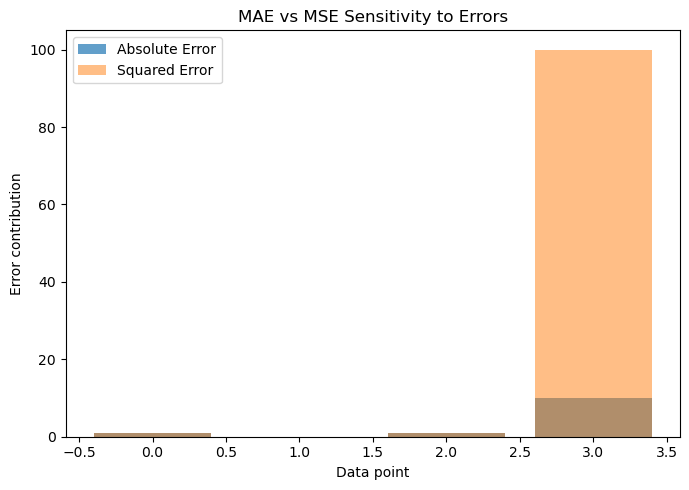

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# True and predicted values
y_true = np.array([2, 4, 6, 20])   # includes an outlier
y_pred = np.array([3, 4, 7, 10])

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")

# Visualisation
errors = y_true - y_pred

plt.figure(figsize=(7,5))
plt.bar(range(len(errors)), np.abs(errors), label="Absolute Error", alpha=0.7)
plt.bar(range(len(errors)), errors**2, alpha=0.5, label="Squared Error")
plt.xlabel("Data point")
plt.ylabel("Error contribution")
plt.title("MAE vs MSE Sensitivity to Errors")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/mae_vs_mse.pdf", dpi=300, bbox_inches="tight")

plt.show()

MSE: 1.50
RMSE: 1.22


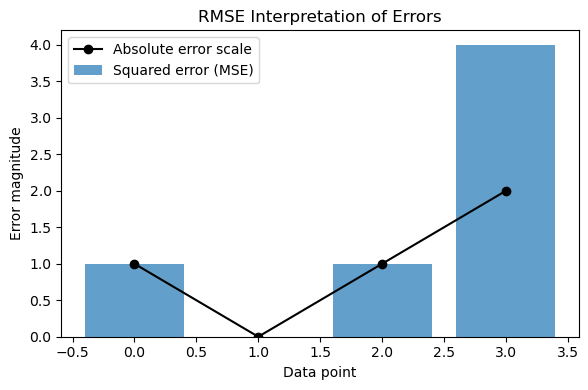

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# True and predicted values
y_true = np.array([2, 4, 6, 8])
y_pred = np.array([3, 4, 7, 10])

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Visualisation
errors = y_true - y_pred

plt.figure(figsize=(6,4))
plt.bar(range(len(errors)), errors**2, label="Squared error (MSE)", alpha=0.7)
plt.plot(range(len(errors)), np.abs(errors), 'o-', label="Absolute error scale", color='black')
plt.xlabel("Data point")
plt.ylabel("Error magnitude")
plt.title("RMSE Interpretation of Errors")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/rmse.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Model fitting

R^2: 0.854


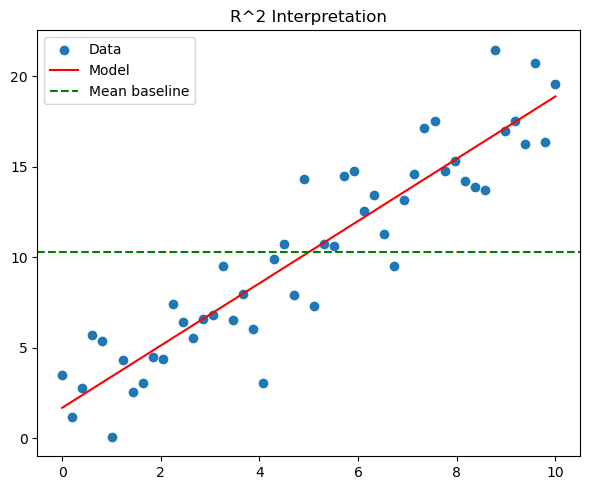

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 10, 50)
y = 2 * X + np.random.randn(50) * 2

# Fit simple model
coef = np.polyfit(X, y, 1)
y_pred = np.polyval(coef, X)

r2 = r2_score(y, y_pred)
print(f"R^2: {r2:.3f}")

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color='red', label="Model")
plt.axhline(y.mean(), color='green', linestyle='--', label="Mean baseline")
plt.title("R^2 Interpretation")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/r2_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()

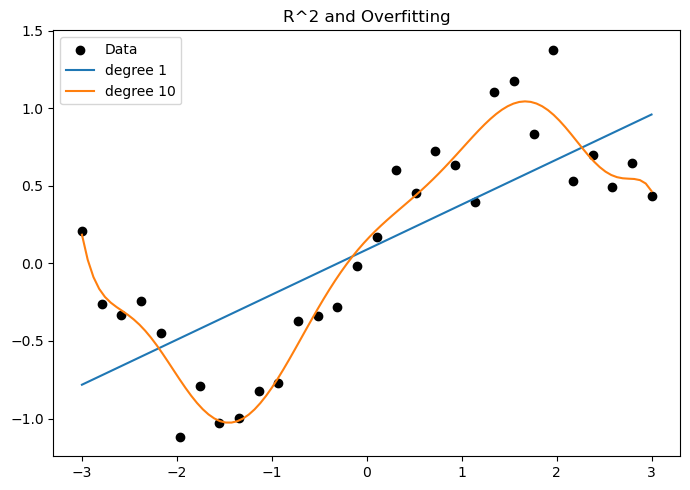

R^2 scores: [0.5671449894108412, 0.9349661763614411]


In [107]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(0)

# Generate data
X = np.linspace(-3, 3, 30)
y = np.sin(X) + np.random.normal(0, 0.2, size=len(X))

X = X.reshape(-1,1)

# Fit models
degrees = [1, 10]
r2_scores = []

plt.figure(figsize=(7,5))
plt.scatter(X, y, color='black', label="Data")

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)
    r2_scores.append(r2_score(y, y_pred))

    X_plot = np.linspace(-3,3,100).reshape(-1,1)
    y_plot = model.predict(poly.transform(X_plot))

    plt.plot(X_plot, y_plot, label=f"degree {d}")

plt.title("R^2 and Overfitting")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/r2_overfitting.pdf", dpi=300, bbox_inches="tight")

plt.show()

print("R^2 scores:", r2_scores)

## Model comparison

Model 1 scores: [0.93  0.95  0.97  0.94  0.935]
Model 2 scores: [0.94  0.97  0.955 0.945 0.935]


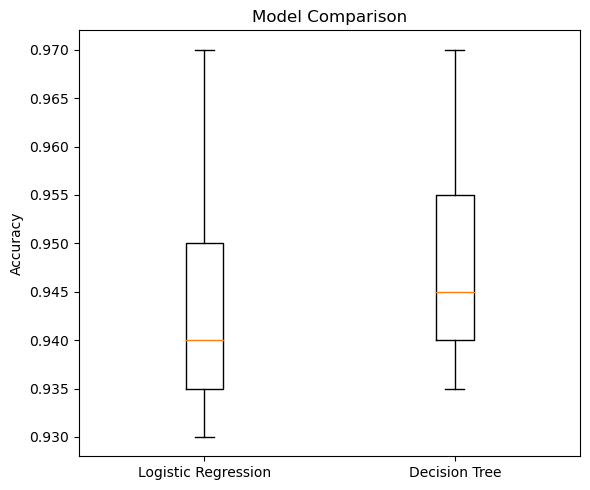

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Generate data
X, y = make_classification(n_samples=1000, n_features=5, random_state=0)

# Models
model1 = LogisticRegression(max_iter=1000)
model2 = DecisionTreeClassifier(max_depth=5)

# Cross-validation scores
scores1 = cross_val_score(model1, X, y, cv=5)
scores2 = cross_val_score(model2, X, y, cv=5)

print("Model 1 scores:", scores1)
print("Model 2 scores:", scores2)

# Plot comparison
plt.figure(figsize=(6,5))
plt.boxplot([scores1, scores2], labels=["Logistic Regression", "Decision Tree"])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.tight_layout()
plt.savefig("/Figures/model_comparison.pdf", dpi=300, bbox_inches="tight")

plt.show()

Simple model: 0.9524000000000001
Complex model: 0.9732


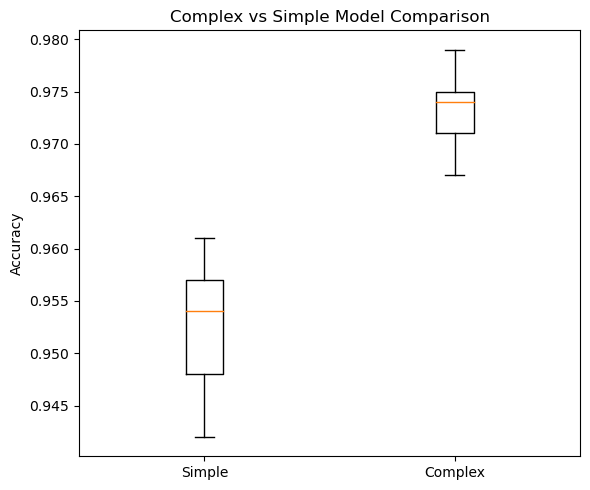

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Generate data
X, y = make_classification(n_samples=5000, n_features=20, random_state=0)

# Models
simple_model = LogisticRegression(max_iter=1000)
complex_model = RandomForestClassifier(n_estimators=100)

# Cross-validation
scores_simple = cross_val_score(simple_model, X, y, cv=5)
scores_complex = cross_val_score(complex_model, X, y, cv=5)

print("Simple model:", scores_simple.mean())
print("Complex model:", scores_complex.mean())

# Plot
plt.figure(figsize=(6,5))
plt.boxplot([scores_simple, scores_complex],
            labels=["Simple", "Complex"])
plt.ylabel("Accuracy")
plt.title("Complex vs Simple Model Comparison")
plt.tight_layout()
plt.savefig("/Figures/model_complex_vs_simple.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Information Criteria

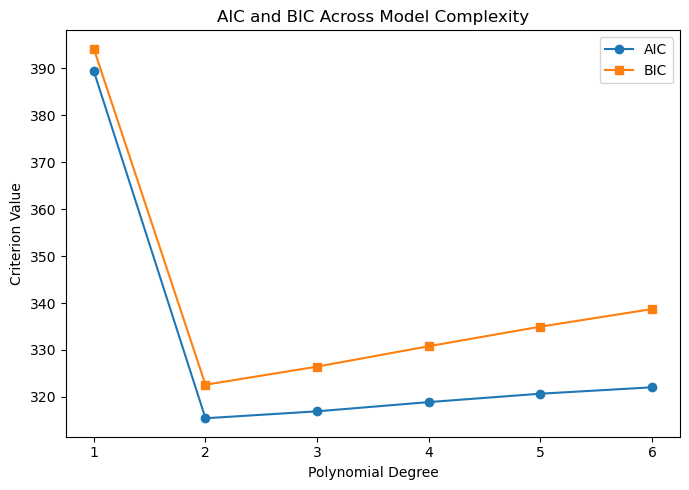

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Generate synthetic nonlinear data
rng = np.random.default_rng(1)
X = np.linspace(-3, 3, 80)
y_true = 1.5 + 2.0 * X - 0.8 * X**2
y = y_true + rng.normal(0, 2.0, size=len(X))

n = len(X)
degrees = range(1, 7)
aic_values = []
bic_values = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X.reshape(-1, 1))

    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)

    residuals = y - y_pred
    rss = np.sum(residuals**2)

    # Gaussian-noise log-likelihood with estimated variance
    sigma2 = rss / n
    logL = -n / 2 * (np.log(2 * np.pi * sigma2) + 1)

    k = X_poly.shape[1]

    aic = 2 * k - 2 * logL
    bic = k * np.log(n) - 2 * logL

    aic_values.append(aic)
    bic_values.append(bic)

plt.figure(figsize=(7, 5))
plt.plot(list(degrees), aic_values, marker="o", label="AIC")
plt.plot(list(degrees), bic_values, marker="s", label="BIC")
plt.xlabel("Polynomial Degree")
plt.ylabel("Criterion Value")
plt.title("AIC and BIC Across Model Complexity")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/AIC_BIC.pdf", dpi=300, bbox_inches="tight")

plt.show()

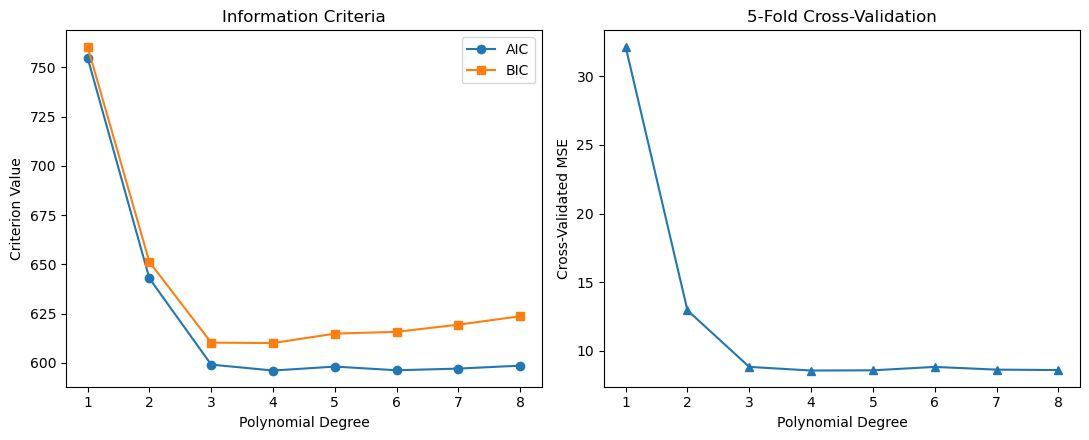

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer

# Generate synthetic nonlinear data
rng = np.random.default_rng(0)
X = np.linspace(-3, 3, 120)
y_true = 1.0 + 2.0 * X - 1.5 * X**2 + 0.4 * X**3
y = y_true + rng.normal(0, 3.0, size=len(X))

X = X.reshape(-1, 1)
n = len(X)

degrees = range(1, 9)
aic_values = []
bic_values = []
cv_mse_values = []

kf = KFold(n_splits=5, shuffle=True, random_state=0)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

for degree in degrees:
    # Fit on full data for AIC/BIC
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly.fit_transform(X)

    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, y)
    y_pred = model.predict(X_poly)

    residuals = y - y_pred
    rss = np.sum(residuals**2)
    sigma2 = rss / n
    logL = -n / 2 * (np.log(2 * np.pi * sigma2) + 1)

    k = X_poly.shape[1]

    aic = 2 * k - 2 * logL
    bic = k * np.log(n) - 2 * logL

    aic_values.append(aic)
    bic_values.append(bic)

    # Cross-validation estimate
    pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=True)),
        ("linreg", LinearRegression(fit_intercept=False))
    ])

    scores = cross_val_score(
        pipeline, X, y, cv=kf, scoring=mse_scorer
    )
    cv_mse_values.append(-scores.mean())

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(list(degrees), aic_values, marker="o", label="AIC")
axes[0].plot(list(degrees), bic_values, marker="s", label="BIC")
axes[0].set_xlabel("Polynomial Degree")
axes[0].set_ylabel("Criterion Value")
axes[0].set_title("Information Criteria")
axes[0].legend()

axes[1].plot(list(degrees), cv_mse_values, marker="^")
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("Cross-Validated MSE")
axes[1].set_title("5-Fold Cross-Validation")

plt.tight_layout()
plt.savefig("/Figures/AIC_BIC_vs_CV.pdf", dpi=300, bbox_inches="tight")

plt.show()

## Statistical Testing

In [123]:
import numpy as np
from scipy.stats import ttest_rel
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Generate data
X, y = make_classification(n_samples=300, n_features=10, random_state=42)

# Models
model1 = LogisticRegression(max_iter=1000)
model2 = DecisionTreeClassifier(max_depth=5)

# Cross-validation scores
scores1 = cross_val_score(model1, X, y, cv=5)
scores2 = cross_val_score(model2, X, y, cv=5)

# Paired t-test
t_stat, p_value = ttest_rel(scores1, scores2)

print("Scores model 1:", scores1)
print("Scores model 2:", scores2)
print(f"p-value: {p_value:.4f}")

Scores model 1: [0.96666667 0.76666667 0.93333333 0.96666667 0.96666667]
Scores model 2: [0.95       0.75       0.93333333 0.95       0.93333333]
p-value: 0.0341


Simulated p-value: 0.047


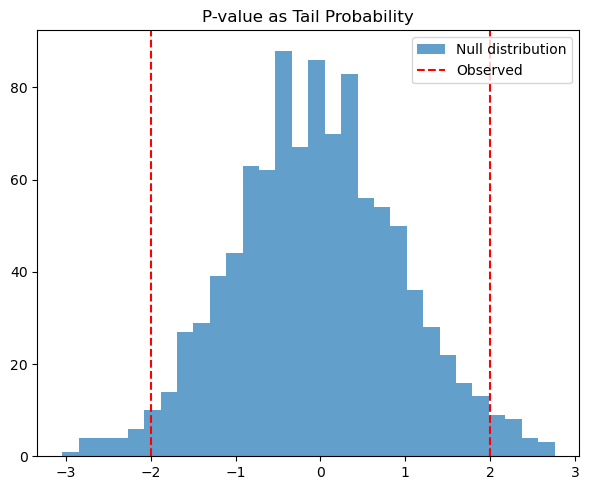

In [124]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Simulate differences under null (mean = 0)
differences = np.random.normal(0, 1, 1000)

# Observed difference
observed = 2.0

# Compute p-value (two-sided)
p_value = np.mean(np.abs(differences) >= observed)

print(f"Simulated p-value: {p_value:.3f}")

# Plot distribution
plt.figure(figsize=(6,5))
plt.hist(differences, bins=30, alpha=0.7, label="Null distribution")
plt.axvline(observed, color='red', linestyle='--', label="Observed")
plt.axvline(-observed, color='red', linestyle='--')
plt.title("P-value as Tail Probability")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/hypothesis_tail.pdf", dpi=300, bbox_inches="tight")

plt.show()

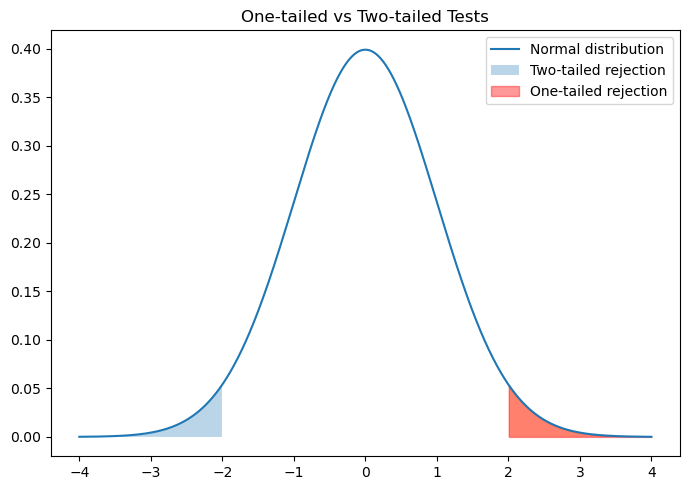

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x)

plt.figure(figsize=(7,5))
plt.plot(x, y, label="Normal distribution")

# Two-tailed regions
plt.fill_between(x, y, where=(x <= -2), alpha=0.3, label="Two-tailed rejection")
plt.fill_between(x, y, where=(x >= 2), alpha=0.3)

# One-tailed region
plt.fill_between(x, y, where=(x >= 2), color='red', alpha=0.4, label="One-tailed rejection")

plt.title("One-tailed vs Two-tailed Tests")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/hypothesis_onetwo.pdf", dpi=300, bbox_inches="tight")

plt.show()

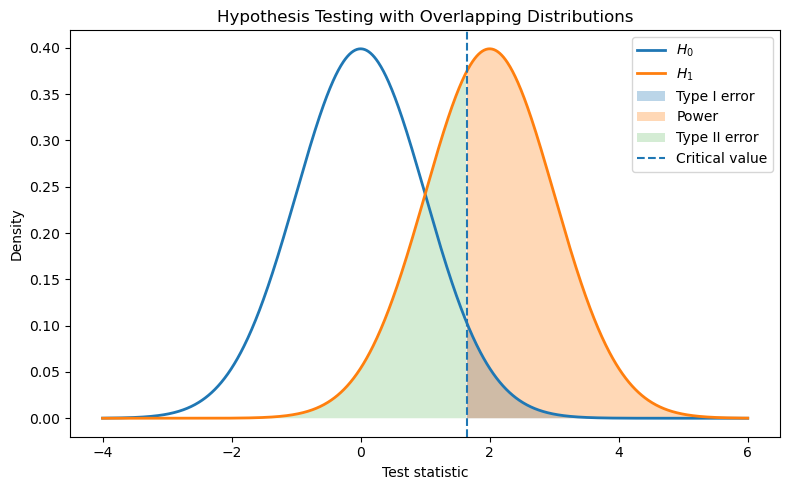

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Grid of test statistic values
x = np.linspace(-4, 6, 1000)

# Null and alternative distributions
h0 = norm.pdf(x, loc=0, scale=1)
h1 = norm.pdf(x, loc=2, scale=1)

# Critical value for a right-tailed test
critical_value = 1.645   # approximately alpha = 0.05 for standard normal

plt.figure(figsize=(8,5))
plt.plot(x, h0, label=r"$H_0$", linewidth=2)
plt.plot(x, h1, label=r"$H_1$", linewidth=2)

# Shade Type I error region under H0
plt.fill_between(
    x, h0, where=(x >= critical_value),
    alpha=0.3, label="Type I error"
)

# Shade power region under H1
plt.fill_between(
    x, h1, where=(x >= critical_value),
    alpha=0.3, label="Power"
)

# Shade Type II error region under H1
plt.fill_between(
    x, h1, where=(x < critical_value),
    alpha=0.2, label="Type II error"
)

plt.axvline(critical_value, linestyle="--", label="Critical value")

plt.xlabel("Test statistic")
plt.ylabel("Density")
plt.title("Hypothesis Testing with Overlapping Distributions")
plt.legend()
plt.tight_layout()

plt.savefig("/Figures/hypothesis_two_dist.pdf", dpi=300, bbox_inches="tight")

plt.show()

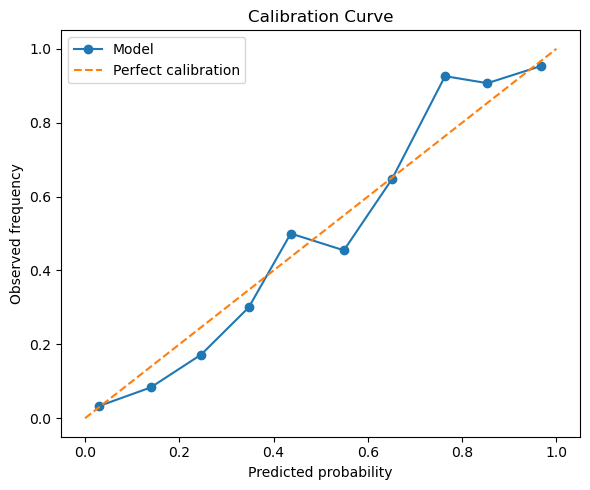

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Generate data
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

model = LogisticRegression()
model.fit(X, y)

probs = model.predict_proba(X)[:, 1]

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(y, probs, n_bins=10)

plt.figure(figsize=(6,5))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label="Model")
plt.plot([0,1], [0,1], linestyle='--', label="Perfect calibration")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig("/Figures/calibration_curve.pdf", dpi=300, bbox_inches="tight")

plt.show()

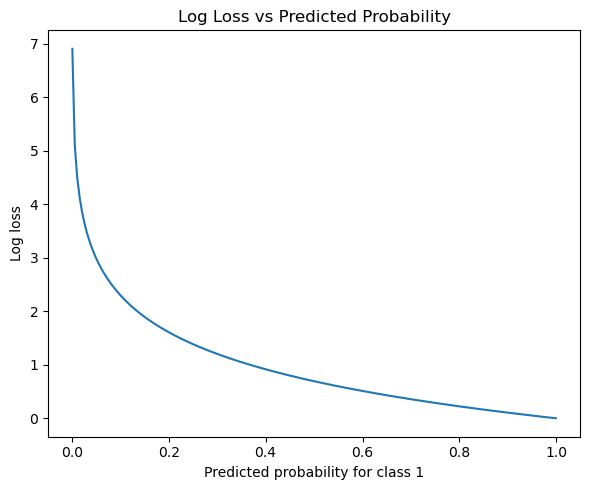

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# True label is 1
probs = np.linspace(0.001, 0.999, 200)

# Binary log loss when y = 1:
# loss = -log(p)
losses = -np.log(probs)

plt.figure(figsize=(6,5))
plt.plot(probs, losses)
plt.xlabel("Predicted probability for class 1")
plt.ylabel("Log loss")
plt.title("Log Loss vs Predicted Probability")
plt.tight_layout()
plt.savefig("/Figures/log_loss.pdf", dpi=300, bbox_inches="tight")

plt.show()
